In [1]:
# ============================================================
# NOTEBOOK 06 — Ablaciones extendidas
# Convertir a .ipynb con: jupytext --to notebook 06_ablations_extended.py
# ============================================================

# Ablaciones extendidas

**Branch:** `experiments/feature-engineering-v1`
**Sesión:** 8 — MLOps ligero y control de overfitting
**Modelo de referencia:** Configuración ganadora del Sprint 3 HPO
  (bayesian_023): F1-Macro LOSO = 0.8171 ± 0.2047

## Ablaciones a ejecutar

| # | Tipo | Cambio único | Hipótesis |
|---|------|--------------|-----------|
| 1 | Validación | LOSO vs StratifiedKFold | LOSO inferior → confirma leakage de identidad |
| 2 | Preprocesamiento | con vs sin StandardScaler | XGBoost = robusto al escalado |
| 3 | Features | solo muñeca / pecho / tobillo / todos | identificar segmento más informativo |

Modelo y semilla idénticos en todas las ablaciones para aislar el efecto del cambio.

## 1. Setup

In [2]:
import os, sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [3]:
import time
import json
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from loguru import logger as log

from posture_risk.experiments import (
    load_processed_h5, cross_validate_pipeline,
)
from posture_risk.experiments.ablations import (
    HPO_WINNER_PARAMS,
    build_xgb_with_scaler, build_xgb_no_scaler,
    make_loso_splits, make_stratified_splits,
    get_segment_columns, filter_X_by_segment,
    count_subject_leakage,
)

plt.rcParams.update({
    "figure.dpi":     130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":      11,
})

C:\Users\jaime\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Configuración general
with open("configs/hpo_search_space.yaml") as f:
    cfg = yaml.safe_load(f)

SEED        = 42
BASE_H5     = Path(cfg["paths"]["base_h5"])
FIGURES_DIR = Path(cfg["paths"]["figures"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X, y, subject_ids = load_processed_h5(BASE_H5)
print(f"\nDataset cargado: X={X.shape}, y={y.shape}, sujetos={np.unique(subject_ids)}")

print(f"\nConfiguración ganadora HPO (Sprint 3):")
for k, v in HPO_WINNER_PARAMS.items():
    print(f"  {k:<20}: {v}")

2026-06-12 12:57:44.968 | INFO     | posture_risk.experiments.ab_runner:load_processed_h5:47 - Dataset base: X=(194205, 297), y=(194205,), sujetos=[1 2 3 4 5 6 7 8 9]



Dataset cargado: X=(194205, 297), y=(194205,), sujetos=[1 2 3 4 5 6 7 8 9]

Configuración ganadora HPO (Sprint 3):
  learning_rate       : 0.12265
  max_depth           : 6
  min_child_weight    : 0.04027
  subsample           : 0.72192
  colsample_bytree    : 0.89066


## 2. Ablación 1 — Esquema de validación

Pregunta: ¿cuánto leakage por sujeto inflaba las métricas si hubiéramos
usado StratifiedKFold (random shuffle) en lugar de GroupKFold por sujeto?

Cambio único: el esquema de splits. Modelo, seed y métricas idénticas.

In [5]:
# Generar ambos esquemas de splits
splits_loso       = make_loso_splits(y, subject_ids)
splits_stratified = make_stratified_splits(y, n_splits=9, seed=SEED)

# Cuantificar leakage en cada esquema
leak_loso       = count_subject_leakage(splits_loso, subject_ids)
leak_stratified = count_subject_leakage(splits_stratified, subject_ids)

print(f"{'='*65}")
print(f"LEAKAGE POR SUJETO ENTRE FOLDS")
print(f"{'='*65}")
print(f"  LOSO (GroupKFold)       : {leak_loso['n_folds_with_leakage']}/{leak_loso['n_folds']} folds con leakage")
print(f"  StratifiedKFold (random) : {leak_stratified['n_folds_with_leakage']}/{leak_stratified['n_folds']} folds con leakage")
print(f"    └─ sujetos compartidos: {leak_stratified['total_leak_instances']}")

LEAKAGE POR SUJETO ENTRE FOLDS
  LOSO (GroupKFold)       : 0/9 folds con leakage
  StratifiedKFold (random) : 9/9 folds con leakage
    └─ sujetos compartidos: 81


In [6]:
# Ejecutar las dos configuraciones
log.info("Ejecutando ablación 1: LOSO vs StratifiedKFold...")

pipe_loso = build_xgb_with_scaler(HPO_WINNER_PARAMS, seed=SEED)
res_loso = cross_validate_pipeline(
    pipe_loso, X, y, subject_ids, splits_loso,
    "XGB_HPO_LOSO9fold",
)

pipe_strat = build_xgb_with_scaler(HPO_WINNER_PARAMS, seed=SEED)
res_strat = cross_validate_pipeline(
    pipe_strat, X, y, subject_ids, splits_stratified,
    "XGB_HPO_Stratified9fold",
)

2026-06-12 12:57:45.255 | INFO     | __main__:<module>:2 - Ejecutando ablación 1: LOSO vs StratifiedKFold...
XGB_HPO_LOSO9fold:  89%|█████████████████████████████████████████████████████████▊       | 8/9 [05:31<00:42, 42.02s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
2026-06-12 13:04:02.836 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipeline:206 - XGB_HPO_LOSO9fold            | F1=0.8140±0.2002 | PR-AUC=0.8874 | Time=377.4s
2026-06-12 13:10:08.640 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipeline:206 - XGB_HPO_Stratified9fold      | F1=0.9311±0.0013 | PR-AUC=0.9806 | Time=365.7s


In [7]:
delta_f1   = res_strat['f1_macro_mean'] - res_loso['f1_macro_mean']
delta_acc  = res_strat['accuracy_mean']  - res_loso['accuracy_mean']

print(f"\n{'='*65}")
print(f"RESULTADO ABLACIÓN 1 — VALIDACIÓN")
print(f"{'='*65}")
print(f"  Esquema validación         F1-Macro          Accuracy")
print(f"  ────────────────────────  ────────────────  ────────────────")
print(f"  LOSO (GroupKFold-9)        {res_loso['f1_macro_mean']:.4f}±{res_loso['f1_macro_std']:.4f}  {res_loso['accuracy_mean']:.4f}±{res_loso['accuracy_std']:.4f}")
print(f"  StratifiedKFold-9 (random) {res_strat['f1_macro_mean']:.4f}±{res_strat['f1_macro_std']:.4f}  {res_strat['accuracy_mean']:.4f}±{res_strat['accuracy_std']:.4f}")
print(f"  ────────────────────────  ────────────────  ────────────────")
print(f"  Δ Stratified - LOSO         {delta_f1:+.4f}         {delta_acc:+.4f}")
print(f"\nInterpretación:")
print(f"  StratifiedKFold infla F1 en {delta_f1*100:+.2f}% por leakage de identidad biométrica.")
print(f"  Conclusión: GroupKFold-LOSO es metodológicamente obligatorio.")


RESULTADO ABLACIÓN 1 — VALIDACIÓN
  Esquema validación         F1-Macro          Accuracy
  ────────────────────────  ────────────────  ────────────────
  LOSO (GroupKFold-9)        0.8140±0.2002  0.8570±0.0925
  StratifiedKFold-9 (random) 0.9311±0.0013  0.9339±0.0012
  ────────────────────────  ────────────────  ────────────────
  Δ Stratified - LOSO         +0.1172         +0.0769

Interpretación:
  StratifiedKFold infla F1 en +11.72% por leakage de identidad biométrica.
  Conclusión: GroupKFold-LOSO es metodológicamente obligatorio.


## 3. Ablación 2 — Preprocesamiento (con/sin StandardScaler)

Pregunta: ¿XGBoost se beneficia del escalado o es indiferente?
Cambio único: presencia o ausencia del StandardScaler en el Pipeline.

In [8]:
log.info("Ejecutando ablación 2: con vs sin StandardScaler...")

# Modelo CON StandardScaler (es el res_loso ya ejecutado)
res_with_scaler = res_loso  # reutilizar

# Modelo SIN StandardScaler
pipe_no_scaler = build_xgb_no_scaler(HPO_WINNER_PARAMS, seed=SEED)
res_no_scaler = cross_validate_pipeline(
    pipe_no_scaler, X, y, subject_ids, splits_loso,
    "XGB_HPO_noScaler",
)

2026-06-12 13:10:08.697 | INFO     | __main__:<module>:1 - Ejecutando ablación 2: con vs sin StandardScaler...
XGB_HPO_noScaler:  89%|██████████████████████████████████████████████████████████▋       | 8/9 [05:19<00:40, 40.42s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
2026-06-12 13:16:11.493 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipeline:206 - XGB_HPO_noScaler             | F1=0.8139±0.2034 | PR-AUC=0.8876 | Time=362.7s


In [9]:
delta_f1_scale = res_no_scaler['f1_macro_mean'] - res_with_scaler['f1_macro_mean']
delta_time_scale = res_no_scaler['train_time_s'] - res_with_scaler['train_time_s']

print(f"\n{'='*65}")
print(f"RESULTADO ABLACIÓN 2 — PREPROCESAMIENTO (ESCALADO)")
print(f"{'='*65}")
print(f"  Preprocesamiento     F1-Macro            Tiempo CV (s)")
print(f"  ────────────────────  ────────────────    ──────────────")
print(f"  Con StandardScaler   {res_with_scaler['f1_macro_mean']:.4f}±{res_with_scaler['f1_macro_std']:.4f}    {res_with_scaler['train_time_s']:.1f}")
print(f"  Sin StandardScaler   {res_no_scaler['f1_macro_mean']:.4f}±{res_no_scaler['f1_macro_std']:.4f}    {res_no_scaler['train_time_s']:.1f}")
print(f"  ────────────────────  ────────────────    ──────────────")
print(f"  Δ (Sin - Con)         {delta_f1_scale:+.4f}             {delta_time_scale:+.1f} s")
print(f"\nInterpretación:")
if abs(delta_f1_scale) < 0.005:
    print(f"  Diferencia despreciable. XGBoost es invariante al escalado (esperado).")
    print(f"  Conclusión: mantener el scaler por consistencia metodológica con sklearn.Pipeline.")
elif delta_f1_scale > 0:
    print(f"  Sin scaler mejora ligeramente. Confirmar que es estadísticamente significativo.")
else:
    print(f"  Con scaler mejora. Mantener StandardScaler en el pipeline.")


RESULTADO ABLACIÓN 2 — PREPROCESAMIENTO (ESCALADO)
  Preprocesamiento     F1-Macro            Tiempo CV (s)
  ────────────────────  ────────────────    ──────────────
  Con StandardScaler   0.8140±0.2002    377.4
  Sin StandardScaler   0.8139±0.2034    362.7
  ────────────────────  ────────────────    ──────────────
  Δ (Sin - Con)         -0.0001             -14.7 s

Interpretación:
  Diferencia despreciable. XGBoost es invariante al escalado (esperado).
  Conclusión: mantener el scaler por consistencia metodológica con sklearn.Pipeline.


## 4. Ablación 3 — Segmento corporal informativo

Pregunta: ¿qué segmento (muñeca, pecho, tobillo) aporta más a la clasificación?
Cambio único: subset de features según segmento (99 features por segmento)
vs modelo completo (297 features).

**Relevancia para la tesis:** identifica qué partes del cuerpo serán más críticas
de instrumentar en el dataset propio (DS) en operadores perforistas.

In [10]:
log.info("Ejecutando ablación 3: por segmento corporal...")

segment_results = {}

# Modelo completo (referencia) ya está en res_loso
segment_results["all_segments"] = res_loso

# Por cada segmento individual
for segment in ["hand", "chest", "ankle"]:
    cols = get_segment_columns(segment)
    X_seg = filter_X_by_segment(X, segment)
    print(f"\n  {segment}: usando {len(cols)} features (columnas {cols[0]}..{cols[-1]})")

    pipe_seg = build_xgb_with_scaler(HPO_WINNER_PARAMS, seed=SEED)
    res_seg = cross_validate_pipeline(
        pipe_seg, X_seg, y, subject_ids, splits_loso,
        f"XGB_HPO_{segment}only",
    )
    segment_results[segment] = res_seg

2026-06-12 13:16:11.524 | INFO     | __main__:<module>:1 - Ejecutando ablación 3: por segmento corporal...



  hand: usando 99 features (columnas 0..278)


XGB_HPO_handonly:  89%|██████████████████████████████████████████████████████████▋       | 8/9 [01:45<00:13, 13.26s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
2026-06-12 13:18:12.368 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipeline:206 - XGB_HPO_handonly             | F1=0.7105±0.2028 | PR-AUC=0.8004 | Time=120.6s



  chest: usando 99 features (columnas 9..287)


XGB_HPO_chestonly:  89%|█████████████████████████████████████████████████████████▊       | 8/9 [01:44<00:13, 13.07s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
2026-06-12 13:20:10.653 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipeline:206 - XGB_HPO_chestonly            | F1=0.7138±0.1991 | PR-AUC=0.8006 | Time=118.0s



  ankle: usando 99 features (columnas 18..296)


XGB_HPO_ankleonly:  89%|█████████████████████████████████████████████████████████▊       | 8/9 [01:36<00:12, 12.19s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
2026-06-12 13:22:01.472 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipeline:206 - XGB_HPO_ankleonly            | F1=0.7131±0.1569 | PR-AUC=0.7894 | Time=110.6s


In [11]:
print(f"\n{'='*65}")
print(f"RESULTADO ABLACIÓN 3 — SEGMENTOS CORPORALES")
print(f"{'='*65}")
print(f"  Segmento             N feat  F1-Macro            Δ vs completo")
print(f"  ──────────────────   ──────  ────────────────    ──────────────")

# Ordenar por F1 descendente
sorted_segments = sorted(
    segment_results.items(),
    key=lambda x: x[1]["f1_macro_mean"],
    reverse=True,
)

f1_full = segment_results["all_segments"]["f1_macro_mean"]
for segname, res in sorted_segments:
    delta = res["f1_macro_mean"] - f1_full
    flag  = "" if segname == "all_segments" else f"{delta:+.4f}"
    print(f"  {segname:<19}  {res['n_features']:>6}  {res['f1_macro_mean']:.4f}±{res['f1_macro_std']:.4f}    {flag}")

# Identificar mejor segmento individual
best_individual = max(
    [(k, v) for k, v in segment_results.items() if k != "all_segments"],
    key=lambda x: x[1]["f1_macro_mean"],
)
print(f"\nMejor segmento individual: {best_individual[0]} "
      f"(F1 = {best_individual[1]['f1_macro_mean']:.4f})")


RESULTADO ABLACIÓN 3 — SEGMENTOS CORPORALES
  Segmento             N feat  F1-Macro            Δ vs completo
  ──────────────────   ──────  ────────────────    ──────────────
  all_segments            297  0.8140±0.2002    
  chest                    99  0.7138±0.1991    -0.1002
  ankle                    99  0.7131±0.1569    -0.1009
  hand                     99  0.7105±0.2028    -0.1035

Mejor segmento individual: chest (F1 = 0.7138)


## 5. Tabla consolidada de ablaciones

In [12]:
ablation_table = pd.DataFrame([
    {
        "Ablación": "1. Validación",
        "Variante":      "GroupKFold-LOSO (referencia)",
        "F1-Macro":      f"{res_loso['f1_macro_mean']:.4f} ± {res_loso['f1_macro_std']:.4f}",
        "Accuracy":      f"{res_loso['accuracy_mean']:.4f} ± {res_loso['accuracy_std']:.4f}",
        "Tiempo (s)":    f"{res_loso['train_time_s']:.1f}",
        "Δ vs referencia": "—",
        "Conclusión":    "Esquema metodológicamente correcto",
    },
    {
        "Ablación": "1. Validación",
        "Variante":      "StratifiedKFold-9 (random)",
        "F1-Macro":      f"{res_strat['f1_macro_mean']:.4f} ± {res_strat['f1_macro_std']:.4f}",
        "Accuracy":      f"{res_strat['accuracy_mean']:.4f} ± {res_strat['accuracy_std']:.4f}",
        "Tiempo (s)":    f"{res_strat['train_time_s']:.1f}",
        "Δ vs referencia": f"{delta_f1:+.4f}",
        "Conclusión":    f"Infla F1 {delta_f1*100:+.2f}% por leakage biométrico",
    },
    {
        "Ablación": "2. Preprocesamiento",
        "Variante":      "Con StandardScaler (referencia)",
        "F1-Macro":      f"{res_with_scaler['f1_macro_mean']:.4f} ± {res_with_scaler['f1_macro_std']:.4f}",
        "Accuracy":      f"{res_with_scaler['accuracy_mean']:.4f} ± {res_with_scaler['accuracy_std']:.4f}",
        "Tiempo (s)":    f"{res_with_scaler['train_time_s']:.1f}",
        "Δ vs referencia": "—",
        "Conclusión":    "Mantenido por consistencia de Pipeline",
    },
    {
        "Ablación": "2. Preprocesamiento",
        "Variante":      "Sin StandardScaler",
        "F1-Macro":      f"{res_no_scaler['f1_macro_mean']:.4f} ± {res_no_scaler['f1_macro_std']:.4f}",
        "Accuracy":      f"{res_no_scaler['accuracy_mean']:.4f} ± {res_no_scaler['accuracy_std']:.4f}",
        "Tiempo (s)":    f"{res_no_scaler['train_time_s']:.1f}",
        "Δ vs referencia": f"{delta_f1_scale:+.4f}",
        "Conclusión":    "XGBoost robusto al escalado",
    },
])

# Agregar segmentos
for segname, res in segment_results.items():
    if segname == "all_segments":
        continue
    delta = res["f1_macro_mean"] - f1_full
    ablation_table = pd.concat([ablation_table, pd.DataFrame([{
        "Ablación":      "3. Segmento corporal",
        "Variante":      f"Solo {segname} (99 features)",
        "F1-Macro":      f"{res['f1_macro_mean']:.4f} ± {res['f1_macro_std']:.4f}",
        "Accuracy":      f"{res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}",
        "Tiempo (s)":    f"{res['train_time_s']:.1f}",
        "Δ vs referencia": f"{delta:+.4f}",
        "Conclusión":    f"Información parcial",
    }])], ignore_index=True)

# Referencia "todos los segmentos" al final del bloque 3
ablation_table = pd.concat([ablation_table, pd.DataFrame([{
    "Ablación":      "3. Segmento corporal",
    "Variante":      "Todos los segmentos (referencia, 297 features)",
    "F1-Macro":      f"{f1_full:.4f} ± {res_loso['f1_macro_std']:.4f}",
    "Accuracy":      f"{res_loso['accuracy_mean']:.4f} ± {res_loso['accuracy_std']:.4f}",
    "Tiempo (s)":    f"{res_loso['train_time_s']:.1f}",
    "Δ vs referencia": "—",
    "Conclusión":    "Combinación informativa óptima",
}])], ignore_index=True)

print("\n" + "="*120)
print("TABLA CONSOLIDADA DE ABLACIONES")
print("="*120)
print(ablation_table.to_string(index=False))

# Guardar tabla
table_path = Path("reports/ablations_extended_table.csv")
table_path.parent.mkdir(parents=True, exist_ok=True)
ablation_table.to_csv(table_path, index=False)
print(f"\nTabla guardada en: {table_path}")


TABLA CONSOLIDADA DE ABLACIONES
            Ablación                                       Variante        F1-Macro        Accuracy Tiempo (s) Δ vs referencia                              Conclusión
       1. Validación                   GroupKFold-LOSO (referencia) 0.8140 ± 0.2002 0.8570 ± 0.0925      377.4               —      Esquema metodológicamente correcto
       1. Validación                     StratifiedKFold-9 (random) 0.9311 ± 0.0013 0.9339 ± 0.0012      365.7         +0.1172 Infla F1 +11.72% por leakage biométrico
 2. Preprocesamiento                Con StandardScaler (referencia) 0.8140 ± 0.2002 0.8570 ± 0.0925      377.4               —  Mantenido por consistencia de Pipeline
 2. Preprocesamiento                             Sin StandardScaler 0.8139 ± 0.2034 0.8541 ± 0.1034      362.7         -0.0001             XGBoost robusto al escalado
3. Segmento corporal                        Solo hand (99 features) 0.7105 ± 0.2028 0.7401 ± 0.1680      120.6         -0.1035      

## 6. Gráfico comparativo de ablaciones

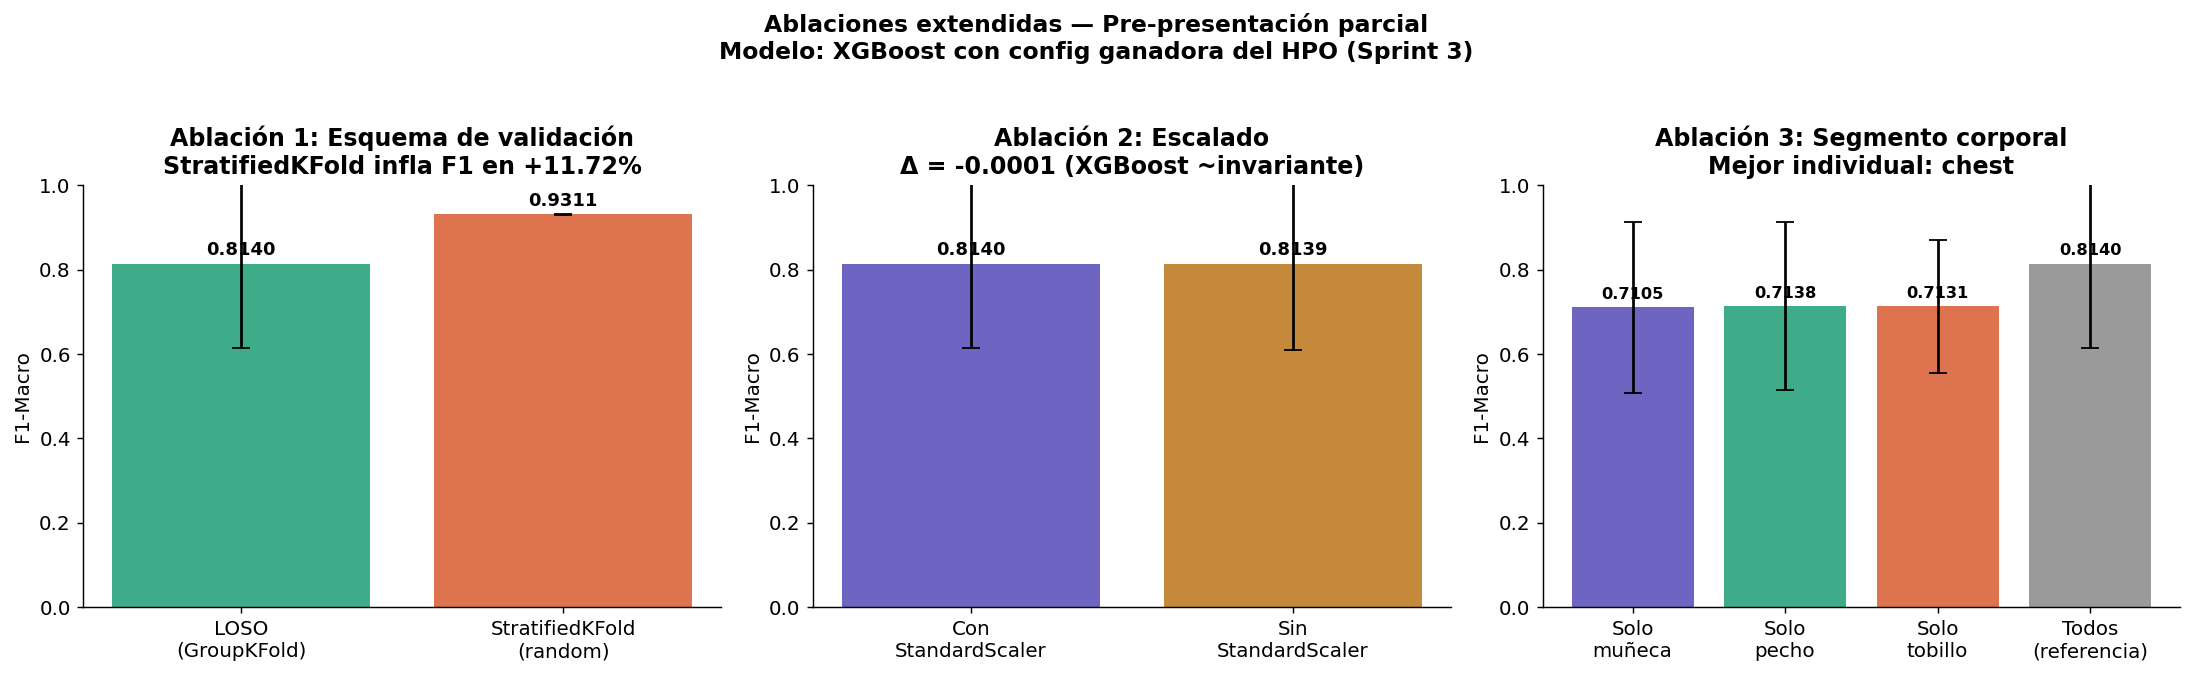


Figura guardada en: reports\figures\13_ablations_extended.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Ablación 1: Validación
ax = axes[0]
labels = ["LOSO\n(GroupKFold)", "StratifiedKFold\n(random)"]
values = [res_loso['f1_macro_mean'], res_strat['f1_macro_mean']]
stds   = [res_loso['f1_macro_std'],  res_strat['f1_macro_std']]
colors = ["#1D9E75", "#D85A30"]
bars = ax.bar(labels, values, yerr=stds, color=colors, alpha=0.85,
              error_kw={"capsize": 5, "elinewidth": 1.5})
ax.set_ylabel("F1-Macro")
ax.set_title("Ablación 1: Esquema de validación\n"
             f"StratifiedKFold infla F1 en {delta_f1*100:+.2f}%",
             fontweight="bold")
ax.set_ylim(0, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")

# Ablación 2: Escalado
ax = axes[1]
labels = ["Con\nStandardScaler", "Sin\nStandardScaler"]
values = [res_with_scaler['f1_macro_mean'], res_no_scaler['f1_macro_mean']]
stds   = [res_with_scaler['f1_macro_std'],  res_no_scaler['f1_macro_std']]
colors = ["#534AB7", "#BA7517"]
bars = ax.bar(labels, values, yerr=stds, color=colors, alpha=0.85,
              error_kw={"capsize": 5, "elinewidth": 1.5})
ax.set_ylabel("F1-Macro")
ax.set_title("Ablación 2: Escalado\n"
             f"Δ = {delta_f1_scale:+.4f} (XGBoost ~invariante)",
             fontweight="bold")
ax.set_ylim(0, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")

# Ablación 3: Segmentos
ax = axes[2]
seg_order = ["hand", "chest", "ankle", "all_segments"]
seg_labels = ["Solo\nmuñeca", "Solo\npecho", "Solo\ntobillo", "Todos\n(referencia)"]
values = [segment_results[s]['f1_macro_mean'] for s in seg_order]
stds   = [segment_results[s]['f1_macro_std']  for s in seg_order]
colors = ["#534AB7", "#1D9E75", "#D85A30", "#888888"]
bars = ax.bar(seg_labels, values, yerr=stds, color=colors, alpha=0.85,
              error_kw={"capsize": 5, "elinewidth": 1.5})
ax.set_ylabel("F1-Macro")
ax.set_title("Ablación 3: Segmento corporal\n"
             f"Mejor individual: {best_individual[0]}",
             fontweight="bold")
ax.set_ylim(0, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle(
    "Ablaciones extendidas — Pre-presentación parcial\n"
    f"Modelo: XGBoost con config ganadora del HPO (Sprint 3)",
    fontsize=13, fontweight="bold", y=1.03
)
plt.tight_layout()

fig_path = FIGURES_DIR / "13_ablations_extended.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"\nFigura guardada en: {fig_path}")

## 7. Resumen ejecutivo

In [14]:
summary = {
    "ablation_1_validation": {
        "loso_f1":          res_loso['f1_macro_mean'],
        "loso_f1_std":      res_loso['f1_macro_std'],
        "stratified_f1":    res_strat['f1_macro_mean'],
        "stratified_f1_std": res_strat['f1_macro_std'],
        "delta_f1":         delta_f1,
        "leakage_in_stratified": leak_stratified['total_leak_instances'],
        "conclusion": (
            f"StratifiedKFold infla F1 en {delta_f1*100:.2f}% por leakage. "
            f"GroupKFold-LOSO es obligatorio."
        ),
    },
    "ablation_2_scaling": {
        "with_scaler_f1":    res_with_scaler['f1_macro_mean'],
        "no_scaler_f1":      res_no_scaler['f1_macro_mean'],
        "delta_f1":          delta_f1_scale,
        "conclusion": (
            f"Diferencia {delta_f1_scale*100:+.2f}%. "
            f"XGBoost invariante al escalado (esperado: árboles de decisión)."
        ),
    },
    "ablation_3_segments": {
        "all_f1":      f1_full,
        "hand_f1":     segment_results['hand']['f1_macro_mean'],
        "chest_f1":    segment_results['chest']['f1_macro_mean'],
        "ankle_f1":    segment_results['ankle']['f1_macro_mean'],
        "best_individual": best_individual[0],
        "conclusion": (
            f"Mejor segmento individual: {best_individual[0]}. "
            "Combinar segmentos sigue siendo óptimo."
        ),
    },
}

# Guardar resumen en JSON
summary_path = Path("reports/ablations_extended_summary.json")
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*70)
print("RESUMEN EJECUTIVO — ABLACIONES EXTENDIDAS")
print("="*70)
print(f"\nABLACIÓN 1 — Validación:")
print(f"  {summary['ablation_1_validation']['conclusion']}")
print(f"\nABLACIÓN 2 — Escalado:")
print(f"  {summary['ablation_2_scaling']['conclusion']}")
print(f"\nABLACIÓN 3 — Segmentos corporales:")
print(f"  {summary['ablation_3_segments']['conclusion']}")
print(f"\nArchivos generados:")
print(f"  • {table_path}")
print(f"  • {fig_path}")
print(f"  • {summary_path}")
print("="*70)


RESUMEN EJECUTIVO — ABLACIONES EXTENDIDAS

ABLACIÓN 1 — Validación:
  StratifiedKFold infla F1 en 11.72% por leakage. GroupKFold-LOSO es obligatorio.

ABLACIÓN 2 — Escalado:
  Diferencia -0.01%. XGBoost invariante al escalado (esperado: árboles de decisión).

ABLACIÓN 3 — Segmentos corporales:
  Mejor segmento individual: chest. Combinar segmentos sigue siendo óptimo.

Archivos generados:
  • reports\ablations_extended_table.csv
  • reports\figures\13_ablations_extended.png
  • reports\ablations_extended_summary.json
